In [355]:
## 2D histogrammer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import os
from tqdm import tqdm
from scipy.optimize import curve_fit

mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
mapL = mapdf.iloc[3072:]
mapR = mapdf.iloc[:3072]
mapL = np.round(mapL, 2)
mapR = np.round(mapR, 2)
ycoordsL, countsL = np.unique(mapL.iloc[:, 1], return_counts=True)
zcoordsL, countsL = np.unique(mapL.iloc[:, 2], return_counts=True)
ycoordsR, countsR = np.unique(mapR.iloc[:, 1], return_counts=True)
ycoordsR = ycoordsR[::-1] # To keep view from isocenter outwards
zcoordsR, countsR = np.unique(mapR.iloc[:, 2], return_counts=True)
scanner_arc_L = np.zeros((32, 96))
scanner_arc_R = np.zeros((32, 96))
for i in range(3072):
    scanner_arc_R[np.where(zcoordsR == mapR.iloc[i, 2]), np.where(ycoordsR == mapR.iloc[i, 1])] = i
for i in range(3072):
    scanner_arc_L[np.where(zcoordsL == mapL.iloc[i, 2]), np.where(ycoordsL == mapL.iloc[i, 1])] = i+3072
def loadmap(mapver = 0):
    if mapver == 0:
        mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
    elif mapver == 1:
        mapdf = pd.read_csv('/home/kale-chen/Documents/PET/LUT.txt', sep = ' ', header = None)
    mapL = mapdf.iloc[3072:]
    mapR = mapdf.iloc[:3072]
    mapL = np.round(mapL, 2)
    mapR = np.round(mapR, 2)
    ycoordsL, countsL = np.unique(mapL.iloc[:, 1], return_counts=True)
    zcoordsL, countsL = np.unique(mapL.iloc[:, 2], return_counts=True)
    ycoordsR, countsR = np.unique(mapR.iloc[:, 1], return_counts=True)
    ycoordsR = ycoordsR[::-1] # To keep view from isocenter outwards
    zcoordsR, countsR = np.unique(mapR.iloc[:, 2], return_counts=True)
    scanner_arc_L = np.zeros((32, 96))
    scanner_arc_R = np.zeros((32, 96))
    for i in range(3072):
        scanner_arc_R[np.where(zcoordsR == mapR.iloc[i, 2]), np.where(ycoordsR == mapR.iloc[i, 1])] = i
    for i in range(3072):
        scanner_arc_L[np.where(zcoordsL == mapL.iloc[i, 2]), np.where(ycoordsL == mapL.iloc[i, 1])] = i+3072



heatmapmin, heatmapmax, cmap = 0, 1, plt.get_cmap('RdBu_r') # 'seismic' or 'RdBu' or 'rwb'
def setcmap(colormap = 'RdBu_r'):
    global cmap
    cmap = plt.get_cmap(colormap)
def getcolor(value, cmap = 'RdBu', numdiscretecolors = 20):
    global heatmapmin, heatmapmax
    colormap = plt.get_cmap(cmap)
    if value < heatmapmin:
        return colormap(0.0)
    elif value > heatmapmax:
        return colormap(1.0)
    else:
        return colormap((value - heatmapmin) / (heatmapmax - heatmapmin) * (numdiscretecolors - 2) // 1 / (numdiscretecolors - 2))
def getcolornondiscrete(value, cmap = 'RdBu'):
    global heatmapmin, heatmapmax
    colormap = plt.get_cmap(cmap)
    if value < heatmapmin:
        return colormap(0.0)
    elif value > heatmapmax:
        return colormap(1.0)
    else:
        return colormap((value - heatmapmin) / (heatmapmax - heatmapmin))

acceptancetablepath = '/home/kale-chen/Documents/PET/Sensitivity Normalization/acceptancetable.bin'
geomsensitivitypath = '/home/kale-chen/Documents/PET/Sensitivity Normalization/geomsensitivity.bin'
normpath = '/home/kale-chen/Documents/PET/Sensitivity Normalization/normfactors/'
def prepdata(path, ncol, mode = 'activity', usegeom = False, usenorm = 0):
    num_rows = os.path.getsize(path) // (2 * ncol)
    data = np.memmap(path, dtype = np.int16, mode = 'r', shape = (num_rows, ncol))
    if mode == 'activity':
        eventcounts = np.zeros((3072, 3072), dtype = np.float32)
        for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
            chunk = data[i:i+1000000]
            if ncol == 3 or ncol == 4 or ncol == 2:
                idls = np.asarray(chunk[:, 0], dtype = np.int32)
                idrs = np.asarray(chunk[:, 1], dtype = np.int32)
            elif ncol == 6:
                idls = np.asarray(chunk[:, 1], dtype = np.int32)
                idrs = np.asarray(chunk[:, 3], dtype = np.int32)
            np.add.at(eventcounts, (idls, idrs), 1)
        acceptancetable = np.fromfile(acceptancetablepath, dtype = np.bool).reshape(3072, 3072)
        eventcounts *= acceptancetable
        eventcountsL = eventcounts.sum(axis = 1)
        eventcountsR = eventcounts.sum(axis = 0)
        if usegeom and usenorm > 0:
            print('Mode: using geom and norm')
            geomsensitivity = np.fromfile(geomsensitivitypath, dtype = np.float32).reshape(3072, 3072)
            normL = np.fromfile(normpath + f'it{usenorm-1}L.bin', dtype = np.float32)
            normR = np.fromfile(normpath + f'it{usenorm-1}R.bin', dtype = np.float32)
            predicted = (geomsensitivity * normL[:, None] * normR[None, :])
            predictedL = predicted.sum(axis = 1)
            predictedR = predicted.sum(axis = 0)
            eventcountsL = eventcountsL / predictedL
            eventcountsR = eventcountsR / predictedR
        elif usegeom:
            print('Mode: using geom')
            geomsensitivity = np.fromfile(geomsensitivitypath, dtype = np.float32).reshape(3072, 3072)
            eventcountsL = eventcountsL / geomsensitivity.sum(axis = 1)
            eventcountsR = eventcountsR / geomsensitivity.sum(axis = 0)
        elif usenorm > 0: 
            print('Mode: using norm')
            normL = np.fromfile(normpath + f'it{usenorm-1}L.bin', dtype = np.float32)
            normR = np.fromfile(normpath + f'it{usenorm-1}R.bin', dtype = np.float32)
            normfactors = normL[:, None] * normR[None, :]
            eventcountsL = eventcountsL / normfactors.sum(axis = 1)
            eventcountsR = eventcountsR / normfactors.sum(axis = 0)
        eventcounts = np.concatenate((eventcountsR, eventcountsL), axis = 0)
        return eventcounts / np.median(eventcounts) 
    elif mode == 'timeoffset':
        data = data[:, 1]
    return data
def prepheatmap(data):
    heatmapR = np.zeros((32, 96))
    heatmapL = np.zeros((32, 96))
    for i in range(3072):
        index = np.where(scanner_arc_R == i)
        heatmapR[index] = data[i]
    for i in range(3072, 6144):
        index = np.where(scanner_arc_L == i)
        heatmapL[index] = data[i]
    return heatmapL, heatmapR

def makeheatmap(heatmapL, heatmapR, title = '', cbarlabel = '', savedir = None, deadcondition = lambda x: x == 0, asiclabels = False):
    for i in range(32):
        for j in range(96):
            if deadcondition(heatmapR[i, j]):
                heatmapR[i, j] = -1
            if deadcondition(heatmapL[i, j]):
                heatmapL[i, j] = -1
    blank_color = 'black'
    fig, ax = plt.subplots(figsize = (8, 5.4))
    for z in range(32):
        zspace = z // 8 * 1.2
        for y in range(96):
            yspace = y // 8 * 1.2
            if heatmapL[z, y] != -1:
                rectL = patches.Rectangle((y*3.2 + yspace, -106 + z*3.2 + zspace - 2.135), 3.2, 3.2, facecolor=getcolor(heatmapL[z, y], cmap = cmap))
            else:
                rectL = patches.Rectangle((y*3.2 + yspace, -106 + z*3.2 + zspace - 2.135), 3.2, 3.2, facecolor=blank_color)
            ax = plt.gca()
            ax.add_patch(rectL)
            if heatmapR[z, y] != -1:
                rectR = patches.Rectangle((y*3.2 + yspace, -106 + z*3.2 + zspace + 108.135), 3.2, 3.2, facecolor=getcolor(heatmapR[z, y], cmap = cmap))
            else:
                rectR = patches.Rectangle((y*3.2 + yspace, -106 +z*3.2 + zspace + 108.135), 3.2, 3.2, facecolor=blank_color)
            ax.add_patch(rectR)

    if asiclabels:
        for i in range(4):
            zspace = i * 1.2
            for j in range(12):
                yspace = j * 1.2
                relz, rely = range(i*8, (i+1)*8), range(j*8, (j+1)*8)
                asictotal = 0
                for z in relz:
                    for y in rely:
                        asictotal += heatmapL[z, y]
                asictotal /= 64
                ax.text(j*25.6 + yspace + 12.8, i*25.6 -106 + zspace - 2.135 + 12.8, f'{asictotal:.1f}', ha='center', va='center', fontsize=8, color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        for i in range(4):
            zspace = i * 1.2
            for j in range(12):
                yspace = j * 1.2
                relz, rely = range(i*8, (i+1)*8), range(j*8, (j+1)*8)
                asictotal = 0
                for z in relz:
                    for y in rely:
                        asictotal += heatmapR[z, y]
                asictotal /= 64
                ax.text(j*25.6 + yspace + 12.8, i*25.6 -106 + zspace + 108.135 + 12.8, f'{asictotal:.1f}', ha='center', va='center', fontsize=8, color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
  
                

    bounds = np.linspace(heatmapmin, heatmapmax, 21)
    norm = colors.BoundaryNorm(bounds, cmap.N)
    mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.02, aspect = 40, pad=0.01)
    #diff = heatmapmax - heatmapmin
    #cbar.set_ticks([heatmapmin, heatmapmin+diff*0.05, heatmapmin+diff*0.1, heatmapmin+diff*0.15, heatmapmin+diff*0.2, heatmapmin+diff*0.25, heatmapmin+diff*0.3, heatmapmin+diff*0.35, heatmapmin+diff*0.4, heatmapmin+diff*0.45, heatmapmin+diff*0.5, heatmapmin+diff*0.55, heatmapmin+diff*0.6, heatmapmin+diff*0.65, heatmapmin+diff*0.7, heatmapmin+diff*0.75, heatmapmin+diff*0.8, heatmapmin+diff*0.85, heatmapmin+diff*0.9, heatmapmin+diff*0.95, heatmapmax])

    formatter = ticker.ScalarFormatter(useMathText=True)

    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))
    cbar.ax.yaxis.offsetText.set_visible(True)  # Make sure the offset (e.g., x1e3) is shown
    cbar.ax.yaxis.get_offset_text().set_position((8, 10))  # Move offset (like 1e3) to the right of colorbar
    cbar.ax.yaxis.get_offset_text().set_fontsize(8)
    cbar.formatter = formatter
    cbar.update_ticks()
    cbar.set_ticks([heatmapmin, 
                    heatmapmin + (heatmapmax-heatmapmin)*0.25, 
                    heatmapmin + (heatmapmax-heatmapmin)*0.5, 
                    heatmapmin + (heatmapmax-heatmapmin)*0.75, 
                    heatmapmax])
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label(cbarlabel, rotation=270, labelpad=10, fontsize=8)
    plt.xlim(0,320.4)
    plt.ylim(-108.135, 108.135)
    plt.axis('off')
    #plt.tight_layout()
    plt.title(title, fontsize=10)
    plt.text(-5, 55, 'Right', ha='center', va='center', fontsize=8, color='black', rotation=90)
    plt.text(-5, -55, 'Left', ha='center', va='center', fontsize=8, color='black', rotation=90)
    if savedir:
        plt.savefig(os.path.join(savedir, f'{title}.pdf'), format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

def radialaxialhist(eventcounts):
    radialL = np.sort(np.unique(np.round((np.arctan2(mapL.iloc[:, 1], mapL.iloc[:, 0]) * 180 / np.pi) % 360 - 180, 1))) 
    radialR = np.sort(np.unique(np.round((np.arctan2(mapR.iloc[:, 1], mapR.iloc[:, 0]) * 180 / np.pi + 180) % 360 - 180, 1)))
    axialL = np.unique(np.round(mapL.iloc[:, 2], 1))
    axialR = np.unique(np.round(mapR.iloc[:, 2], 1))
    axialheightsL, axialheightsR = np.zeros(len(axialL)), np.zeros(len(axialR))
    radialheightsL, radialheightsR = np.zeros(len(radialL)), np.zeros(len(radialR))
    for i in range(3072):
        index = np.where(radialL == np.round(np.arctan2(mapL.iloc[i, 1], mapL.iloc[i, 0]) * 180 / np.pi % 360 - 180, 1))
        radialheightsL[index] += eventcounts[i + 3072]
        index = np.where(axialL == np.round(mapL.iloc[i, 2], 1))
        axialheightsL[index] += eventcounts[i + 3072]
    for i in range(3072):
        index = np.where(radialR == np.round((np.arctan2(mapR.iloc[i, 1], mapR.iloc[i, 0]) * 180 / np.pi + 180) % 360 - 180, 1))
        radialheightsR[index] += eventcounts[i]
        index = np.where(axialR == np.round(mapR.iloc[i, 2], 1))
        axialheightsR[index] += eventcounts[i]
    return radialL, radialR, axialL, axialR, radialheightsL / 32, radialheightsR / 32, axialheightsL / 96, axialheightsR / 96



In [210]:
writeupdir = '/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup'

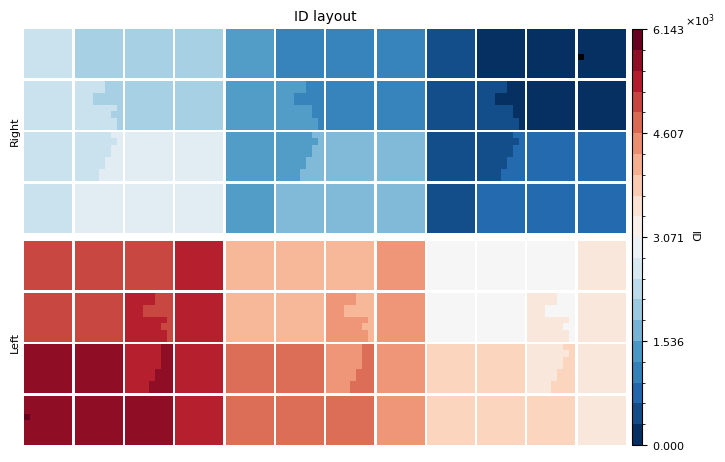

In [211]:
# For checking id layout
ids = range(6144)
heatmapmin, heatmapmax = 0, 6143
heatmapL, heatmapR = prepheatmap(ids)
makeheatmap(heatmapL, heatmapR, title = 'ID layout', cbarlabel = 'ID', savedir = writeupdir + '/images')


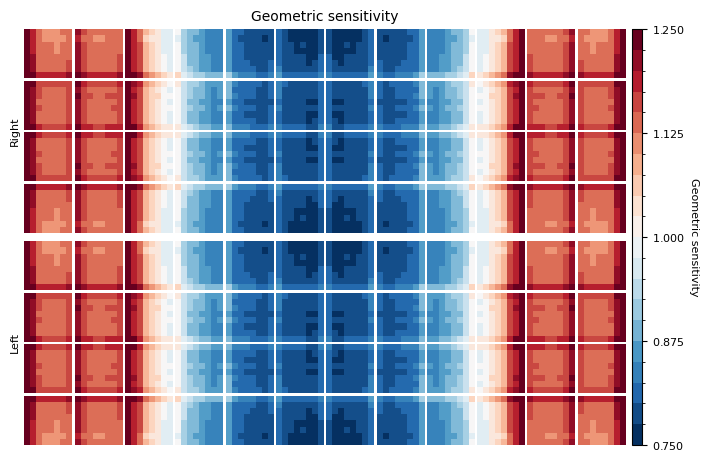

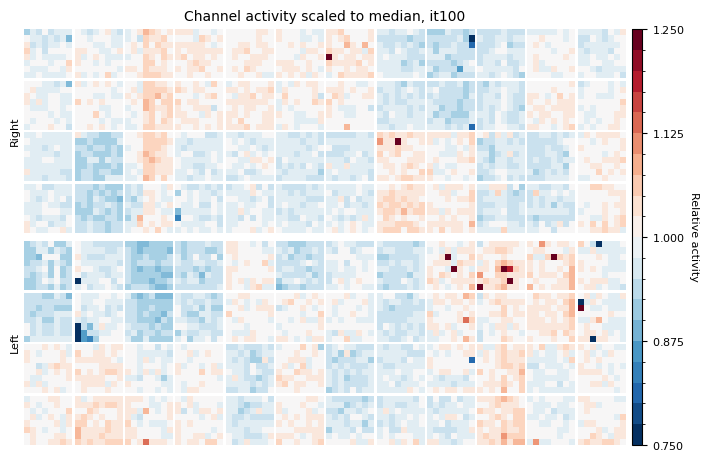

In [299]:
geomsensitivity = np.fromfile('/home/kale-chen/Documents/PET/Sensitivity Normalization/geomsensitivity.bin', dtype = np.float32).reshape(3072, 3072)
geomsensitivityL = np.sum(geomsensitivity, axis = 1)
geomsensitivityR = np.sum(geomsensitivity, axis = 0)
geomsensitivityLR = np.concatenate((geomsensitivityR, geomsensitivityL), axis = 0)
geomsensitivityLR = geomsensitivityLR / np.median(geomsensitivityLR)
heatmapL, heatmapR = prepheatmap(geomsensitivityLR)
heatmapmin, heatmapmax = 0.75, 1.25
makeheatmap(heatmapL, heatmapR, title = 'Geometric sensitivity', cbarlabel = 'Geometric sensitivity')
for it in [100]:
    normfactorsL = np.fromfile(f'/home/kale-chen/Documents/PET/Sensitivity Normalization/normfactors/it{it-1}L.bin', dtype = np.float32)
    normfactorsR = np.fromfile(f'/home/kale-chen/Documents/PET/Sensitivity Normalization/normfactors/it{it-1}R.bin', dtype = np.float32)
    normfactors = np.concatenate((normfactorsR, normfactorsL), axis = 0)
    heatmapL, heatmapR = prepheatmap(normfactors)
    
    makeheatmap(heatmapL, heatmapR, title = f'Channel activity scaled to median, it{it}', cbarlabel = 'Relative activity')

Event counts:   0%|          | 0/20 [00:00<?, ?it/s]

Event counts: 100%|██████████| 20/20 [00:01<00:00, 15.00it/s]


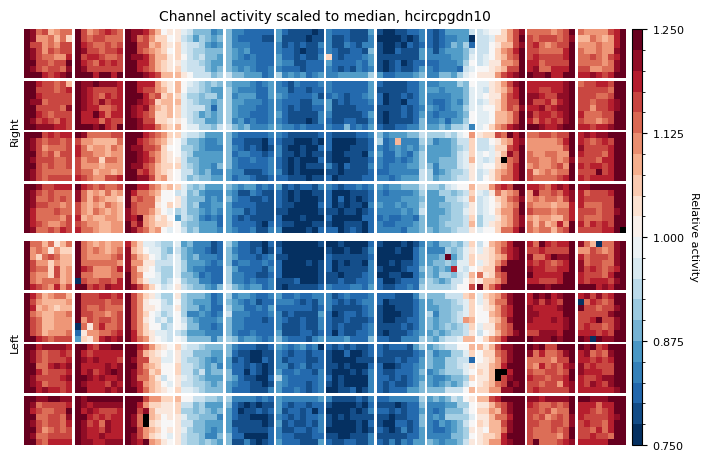

In [375]:
name = 'hcircpgd'
path = f'/home/kale-chen/Documents/PET/TPPT2026/data/{name}.bin'
eventcounts1 = prepdata(path, 4, mode = 'activity', usegeom = False, usenorm = 0)
heatmapL, heatmapR = prepheatmap(eventcounts1)
heatmapmin, heatmapmax = 0.75, 1.25
setcmap('RdBu_r')
#makeheatmap(heatmapL, heatmapR, title = f'Channel activity scaled to median, {name}n', cbarlabel = 'Relative activity')
makeheatmap(heatmapL, heatmapR, title = f'Channel activity scaled to median, {name}n10', cbarlabel = 'Relative activity', savedir = writeupdir + '/plots/activityhist')


Event counts: 100%|██████████| 5/5 [00:00<00:00,  8.23it/s]


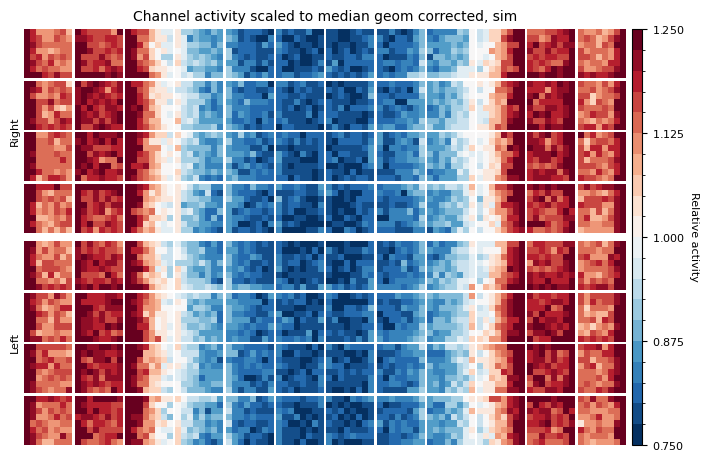

In [376]:
path = '/home/kale-chen/Documents/Geant4/TPPTsim/temp/idsmapped.bin'
eventcounts2 = prepdata(path, 2, mode = 'activity', usegeom = False, usenorm = 0)
heatmapL, heatmapR = prepheatmap(eventcounts2)
makeheatmap(heatmapL, heatmapR, title = 'Channel activity scaled to median geom corrected, sim', cbarlabel = 'Relative activity', savedir = '/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots/activityhist')
#makeheatmap(heatmapL, heatmapR, title = 'Channel activity scaled to median, sim', cbarlabel = 'Relative activity')


[3.05415288e+01 9.99795062e-01 2.85566444e-02]


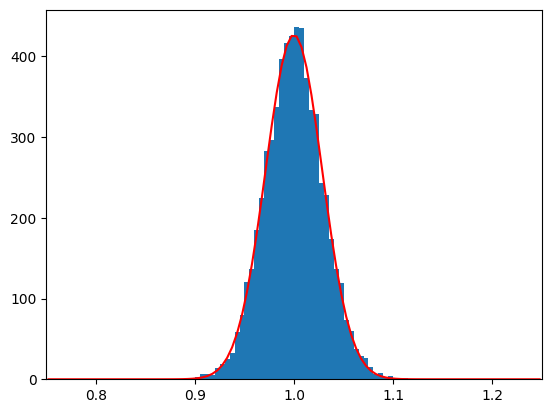

In [372]:
def gaussian(x, a, m, c):
    return a * np.exp(-(x - m)**2 / (2 * c**2)) / (c * np.sqrt(2 * np.pi))
hist, bins = plt.hist(eventcounts2, bins = np.linspace(0.75, 1.25, 101))[0:2]
popt, _ = curve_fit(gaussian, bins[:-1] + np.diff(bins)[0] / 2, hist, p0 = [np.max(hist), 1, 0.05])
print(popt)
plt.plot(bins[:-1] + np.diff(bins)[0] / 2, gaussian(bins[:-1] + np.diff(bins)[0] / 2, *popt), label = f'it0 FWHM = {2.355 * popt[2]:.4f}', color = 'red')
plt.xlim(0.75, 1.25)
plt.show()

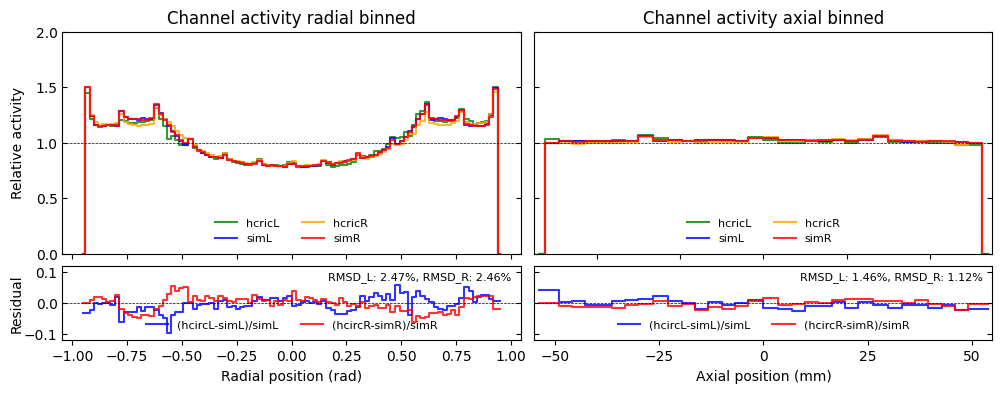

In [378]:
hist1 = radialaxialhist(eventcounts1)
hist2 = radialaxialhist(eventcounts2)
fig, ax = plt.subplots(2, 2, figsize = (12, 4), gridspec_kw = {'width_ratios': [1, 1], 'height_ratios': [3, 1]})
ax = ax.flatten()
def extendbins(bins):
    return np.concatenate(([bins[0] - np.diff(bins)[0]], bins, [bins[-1] + np.diff(bins)[-1]])) 
def extendheights(heights, mode = 'zero'):
    if mode == 'zero':
        return np.concatenate(([0], heights, [0])) 
    elif mode == 'extend':
        return np.concatenate(([heights[0]], heights, [heights[-1]]))
def plotradialaxialhist(bins, heights, color, label, axplot):
    bins, heights = extendbins(bins), extendheights(heights)
    i = len(bins) // 2
    #axplot.step(bins, heights / (heights[i-1] + heights[i]) * 2, color = color, where = 'mid', alpha = 0.8, label = label)
    axplot.step(bins, heights, color = color, where = 'mid', alpha = 0.8, label = label)
plotradialaxialhist(np.flip(hist1[0])* np.pi / 180, hist1[4], 'green', 'hcricL', ax[0])
plotradialaxialhist(np.flip(hist2[0])* np.pi / 180, hist2[4], 'blue', 'simL', ax[0])
plotradialaxialhist(np.flip(hist1[1])* np.pi / 180, hist1[5], 'orange', 'hcricR', ax[0])
plotradialaxialhist(np.flip(hist2[1])* np.pi / 180, hist2[5], 'red', 'simR', ax[0])
ax[2].step(extendbins(np.flip(hist1[0]))* np.pi / 180, extendheights((hist1[4] - hist2[4]) / hist2[4], mode = 'extend'), color = 'blue', where = 'mid', alpha = 0.8, label ='(hcircL-simL)/simL')
ax[2].step(extendbins(np.flip(hist1[1]))* np.pi / 180, extendheights((hist1[5] - hist2[5]) / hist2[5], mode = 'extend'), color = 'red', where = 'mid', alpha = 0.8, label ='(hcircR-simR)/simR')
rmsdradialL = np.sqrt(np.sum(((hist1[4] - hist2[4]) / hist2[4])**2) / len(hist1[4])) * 100
rmsdradialR = np.sqrt(np.sum(((hist1[5] - hist2[5]) / hist2[5])**2) / len(hist1[5])) * 100
ax[2].text(0.98, 0.92, f'RMSD_L: {rmsdradialL:.2f}%, RMSD_R: {rmsdradialR:.2f}%', ha='right', va='top', fontsize=8, color='black', transform=ax[2].transAxes)
plotradialaxialhist(hist1[2], hist1[6], 'green', 'hcricL', ax[1])
plotradialaxialhist(hist2[2], hist2[6], 'blue', 'simL', ax[1])
plotradialaxialhist(hist1[3], hist1[7], 'orange', 'hcricR', ax[1])
plotradialaxialhist(hist2[3], hist2[7], 'red', 'simR', ax[1])
ax[3].step(extendbins(hist1[2]), extendheights((hist1[6] - hist2[6]) / hist2[6], mode = 'extend'), color = 'blue', where = 'mid', alpha = 0.8, label ='(hcircL-simL)/simL')
ax[3].step(extendbins(hist1[3]), extendheights((hist1[7] - hist2[7]) / hist2[7], mode = 'extend'), color = 'red', where = 'mid', alpha = 0.8, label ='(hcircR-simR)/simR')
rmsdaxialL = np.sqrt(np.sum(((hist1[6] - hist2[6]) / hist2[6])**2) / len(hist1[6])) * 100
rmsdaxialR = np.sqrt(np.sum(((hist1[7] - hist2[7]) / hist2[7])**2) / len(hist1[7])) * 100
ax[3].text(0.98, 0.92, f'RMSD_L: {rmsdaxialL:.2f}%, RMSD_R: {rmsdaxialR:.2f}%', ha='right', va='top', fontsize=8, color='black', transform=ax[3].transAxes)
#ax[0].set_xlim(-1.05, 1.05)
#ax[2].set_xlim(-1.05, 1.05)
ax[0].set_ylim(0, 2)
ax[2].set_ylim(-0.12, 0.12)
ax[2].set_xlabel('Radial position (rad)')
ax[0].set_title('Channel activity radial binned')
ax[0].set_ylabel('Relative activity', labelpad=8)
ax[2].set_ylabel('Residual', labelpad=0)
ax[0].set_xticklabels([])

ax[1].set_xlim(-55, 55)
ax[3].set_xlim(-55, 55)
ax[1].set_ylim(0, 2)
ax[3].set_ylim(-0.12, 0.12)
ax[3].set_xlabel('Axial position (mm)')
ax[1].set_title('Channel activity axial binned')
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
ax[3].set_yticklabels([])
ax[3].set_xticks([-50,-25, 0, 25, 50])
for axi in ax:
    axi.yaxis.set_ticks_position('both')
    axi.tick_params(axis='y', which='both', direction='in', left=True, right=True)
    axi.legend(loc = 'lower center', ncol = 2, frameon = False, fontsize = 8)
ax[0].axhline(y = 1, color = 'black', linestyle = '--', linewidth = 0.5)
ax[1].axhline(y = 1, color = 'black', linestyle = '--', linewidth = 0.5)
ax[2].axhline(y = 0, color = 'black', linestyle = '--', linewidth = 0.5)
ax[3].axhline(y = 0, color = 'black', linestyle = '--', linewidth = 0.5)
plt.subplots_adjust(wspace = 0.03, hspace = 0.08)
#plt.tight_layout()
plt.savefig('/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots/activityhist/simpgd.pdf',format='pdf',dpi=300,bbox_inches='tight')
plt.show()

Event counts: 100%|██████████| 20/20 [00:00<00:00, 20.41it/s]


Mode: using geom


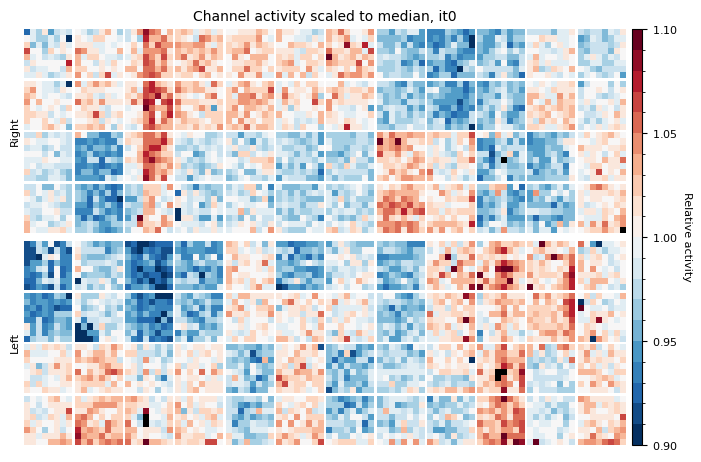

1


Event counts: 100%|██████████| 20/20 [00:00<00:00, 20.68it/s]


Mode: using geom and norm


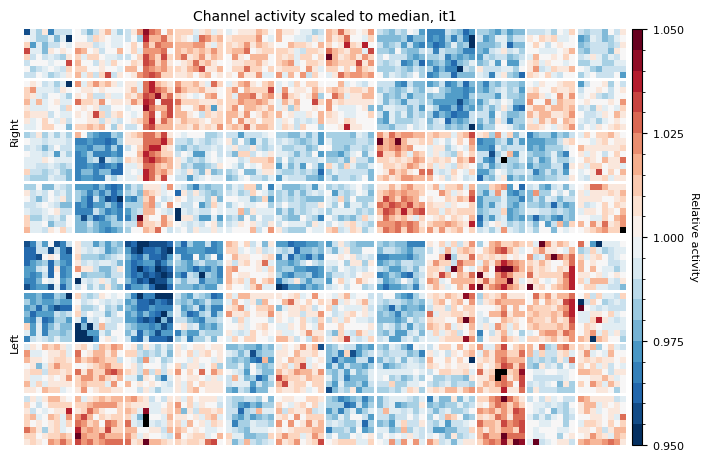

2


Event counts: 100%|██████████| 20/20 [00:01<00:00, 18.73it/s]


Mode: using geom and norm


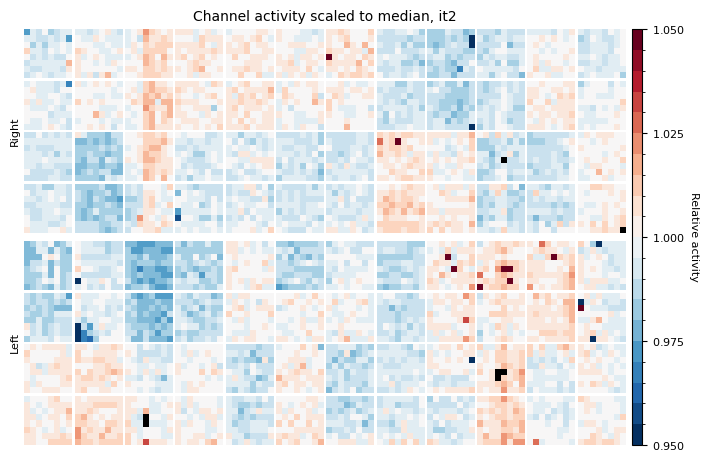

3


Event counts: 100%|██████████| 20/20 [00:00<00:00, 21.14it/s]


Mode: using geom and norm


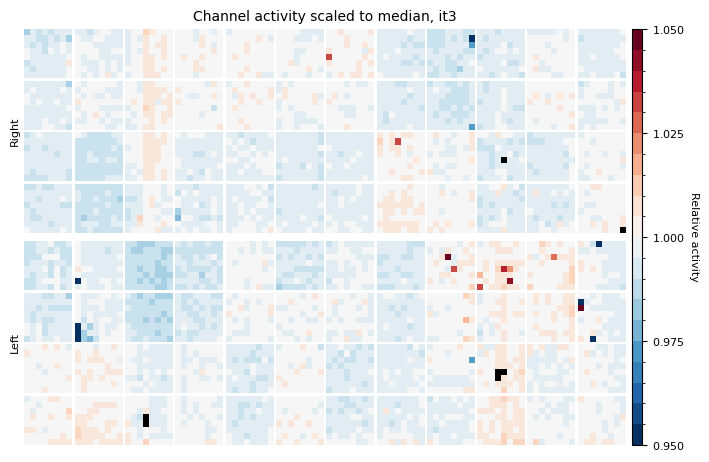

4


Event counts: 100%|██████████| 20/20 [00:01<00:00, 19.19it/s]


Mode: using geom and norm


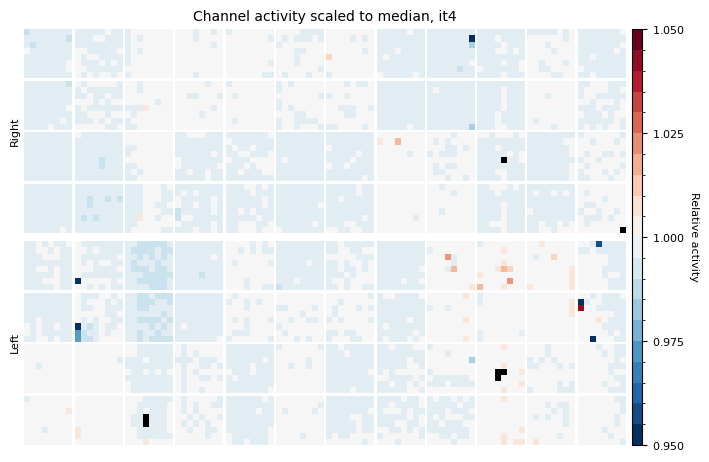

5


Event counts: 100%|██████████| 20/20 [00:01<00:00, 19.75it/s]


Mode: using geom and norm


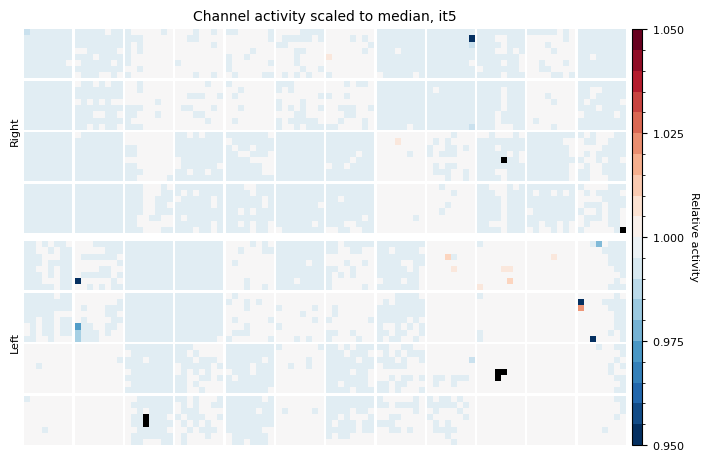

6


Event counts: 100%|██████████| 20/20 [00:00<00:00, 20.64it/s]


Mode: using geom and norm


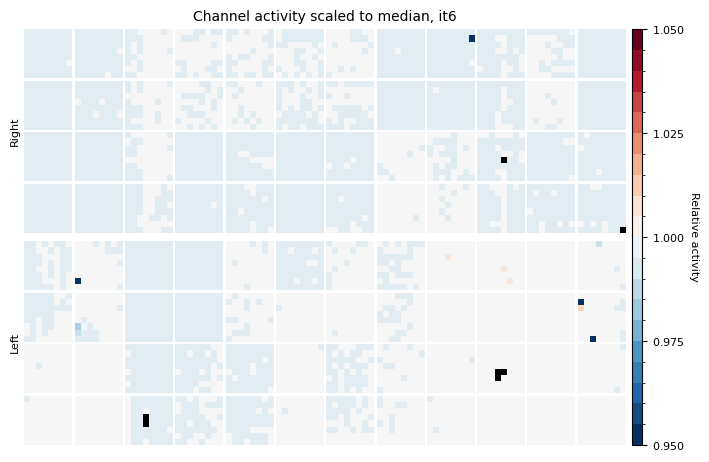

7


Event counts: 100%|██████████| 20/20 [00:00<00:00, 20.38it/s]


Mode: using geom and norm


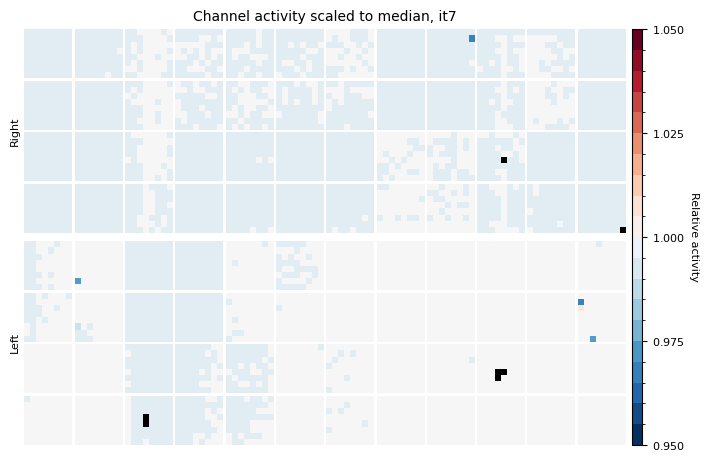

8


Event counts: 100%|██████████| 20/20 [00:01<00:00, 19.56it/s]


Mode: using geom and norm


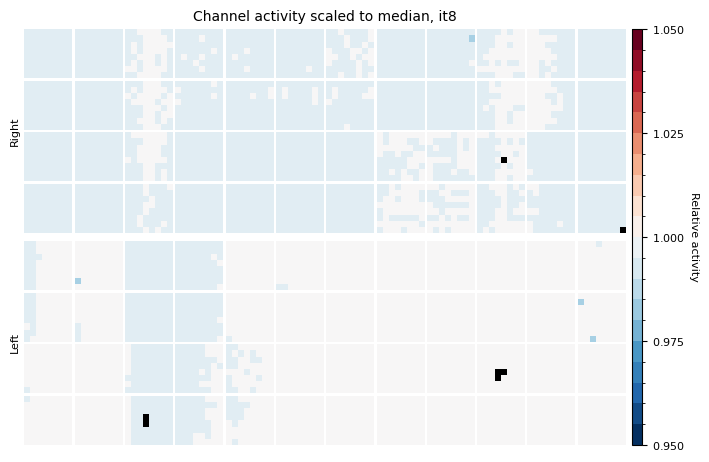

9


Event counts: 100%|██████████| 20/20 [00:00<00:00, 20.76it/s]


Mode: using geom and norm


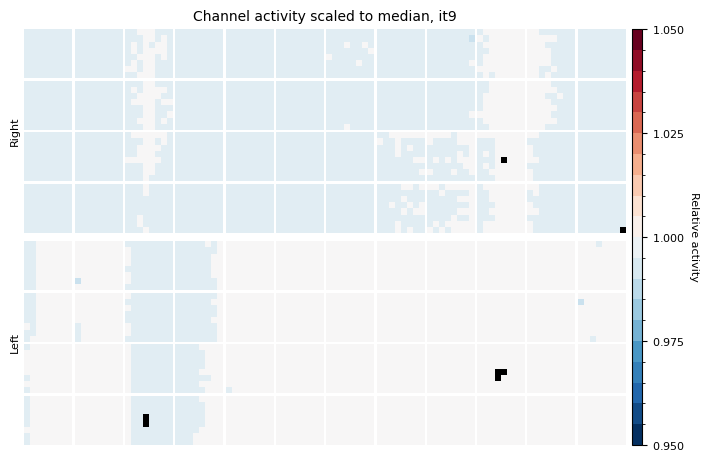

10


Event counts: 100%|██████████| 20/20 [00:00<00:00, 20.03it/s]


Mode: using geom and norm


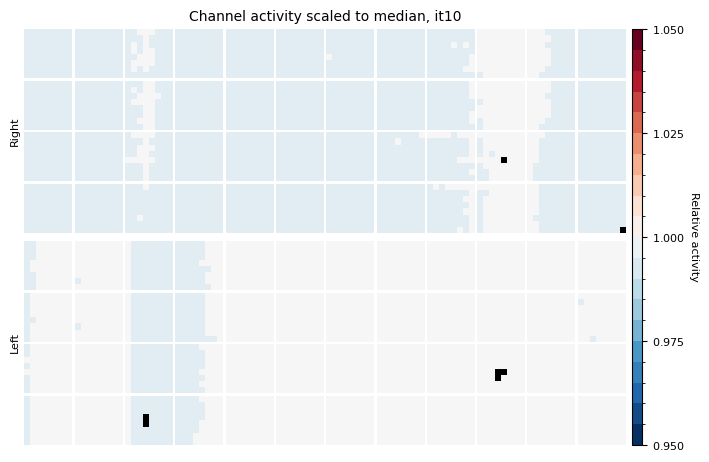

In [329]:
# Apply normalization per LOR
heatmapmin, heatmapmax = 0.9, 1.1
setcmap('RdBu_r')
name = 'hcircpgd'
path = f'/home/kale-chen/Documents/PET/TPPT2026/data/{name}.bin'
eventcounts0 = prepdata(path, 4, mode = 'activity', usegeom = True, usenorm = 0)
heatmapL, heatmapR = prepheatmap(eventcounts0)
makeheatmap(heatmapL, heatmapR, title = 'Channel activity scaled to median, it0', cbarlabel = 'Relative activity', savedir = writeupdir + '/plots/convergence')
iterations = [1, 2, 3, 4, 5, 6, 7,8, 9, 10]
heatmapmin, heatmapmax = 0.95, 1.05
for it in iterations:
    print(it)
    eventcounts = prepdata(path, 4, mode = 'activity', usegeom = True, usenorm = it)
    heatmapL, heatmapR = prepheatmap(eventcounts)
    makeheatmap(heatmapL, heatmapR, title = f'Channel activity scaled to median, it{it}', cbarlabel = 'Relative activity', savedir = writeupdir + '/plots/convergence')

Event counts: 100%|██████████| 20/20 [00:01<00:00, 16.30it/s]


Mode: using geom and norm


Event counts: 100%|██████████| 20/20 [00:00<00:00, 21.36it/s]


Mode: using geom and norm


Event counts: 100%|██████████| 20/20 [00:01<00:00, 19.97it/s]


Mode: using geom and norm


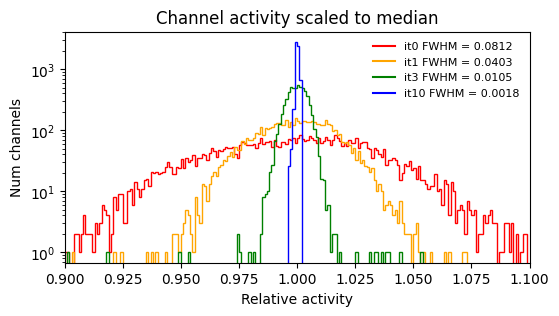

In [351]:
def gaussian(x, a, m, c):
    return a * np.exp(-(x - m)**2 / (2 * c**2)) / (c * np.sqrt(2 * np.pi))
plt.figure(figsize = (6, 3))
bins = np.linspace(.9, 1.1, 201)
hist = plt.hist(eventcounts0, bins = bins, histtype = 'step', color = 'red')[0]
popt, _ = curve_fit(gaussian, bins[:-1] + np.diff(bins)[0] / 2, hist)
plt.plot(0, 0, label = f'it0 FWHM = {2.355 * popt[2]:.4f}', color = 'red')
iterations = [1, 3, 10]
colors = ['orange', 'green', 'blue']
for i in range(len(iterations)):
    eventcounts = prepdata(path, 4, mode = 'activity', usegeom = True, usenorm = iterations[i])
    hist = plt.hist(eventcounts, bins = bins, histtype = 'step', color = colors[i])[0]
    popt, _ = curve_fit(gaussian, bins[:-1] + np.diff(bins)[0] / 2, hist)
    plt.plot(0, 0, label = f'it{iterations[i]} FWHM = {2.355 * popt[2]:.4f}', color = colors[i])
plt.legend(loc = 'upper right', frameon = False, fontsize = 8)
plt.yscale('log')
plt.xlim(0.9, 1.1)
plt.xlabel('Relative activity')
plt.ylabel('Num channels')
plt.title('Channel activity scaled to median')
plt.savefig('/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots/convergence/histselectediterations.pdf',format='pdf',dpi=300,bbox_inches='tight')

plt.show()

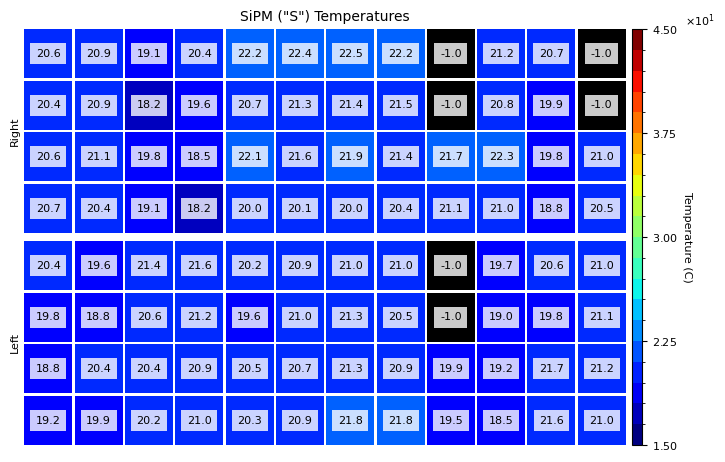

In [252]:
name = 'tempIDorderS2022'
idorder = np.fromfile(f'/home/kale-chen/Documents/PET/TPPT2026/tempanalysis/{name}.bin', dtype = np.float32)
heatmapL, heatmapR = prepheatmap(idorder)
heatmapmin, heatmapmax = 15, 45
setcmap('jet')
if 'A' in name:
    title = 'ASIC ("A") Temperatures'
else:
    title = 'SiPM ("S") Temperatures'
makeheatmap(heatmapL, heatmapR, title = title, cbarlabel = 'Temperature (C)', asiclabels = True)


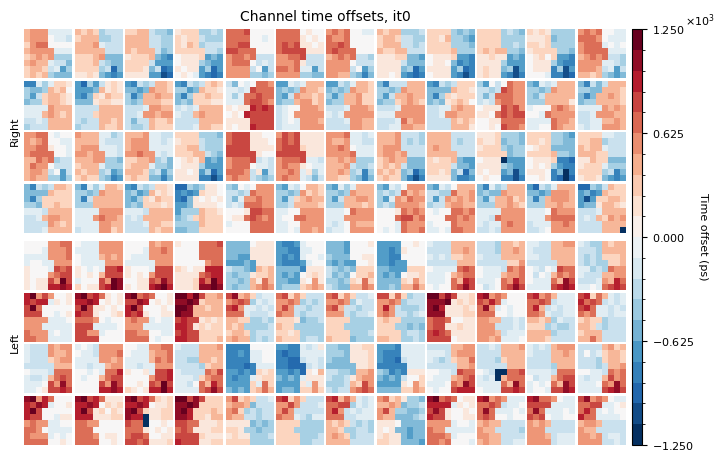

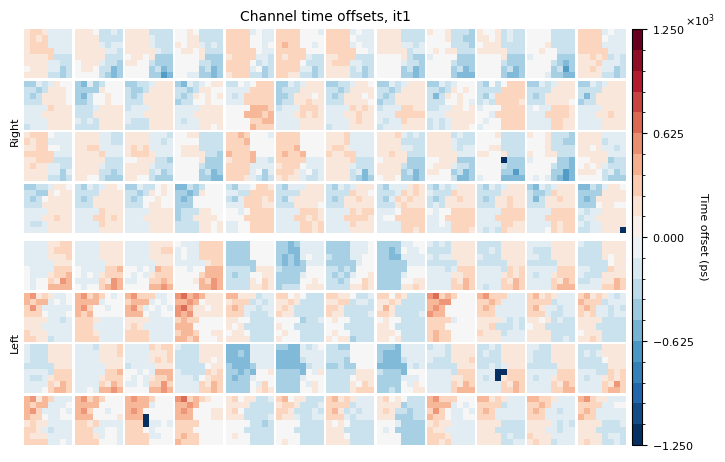

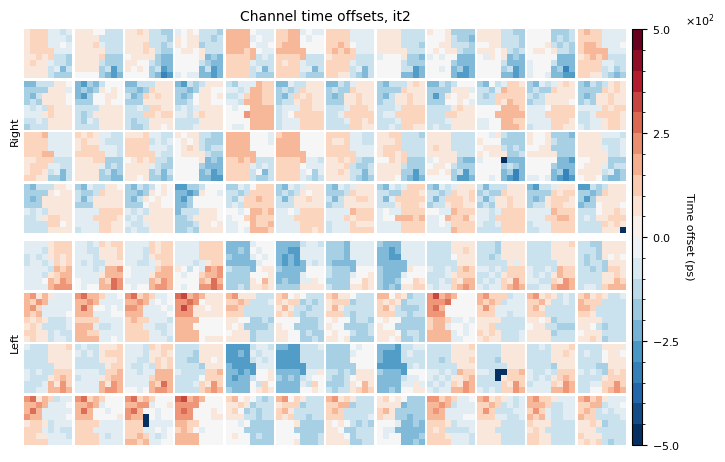

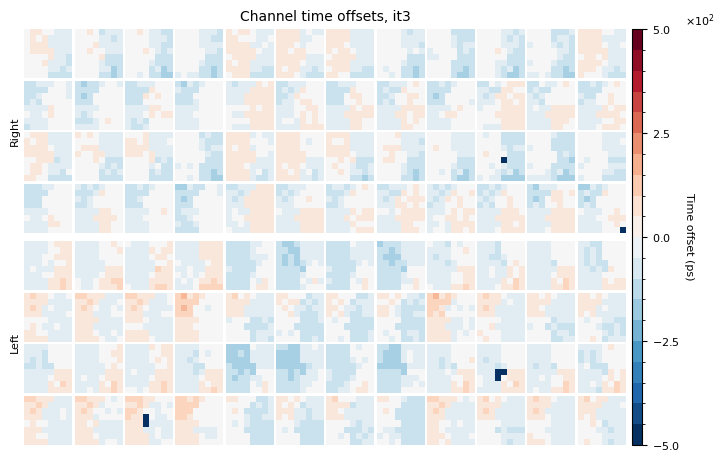

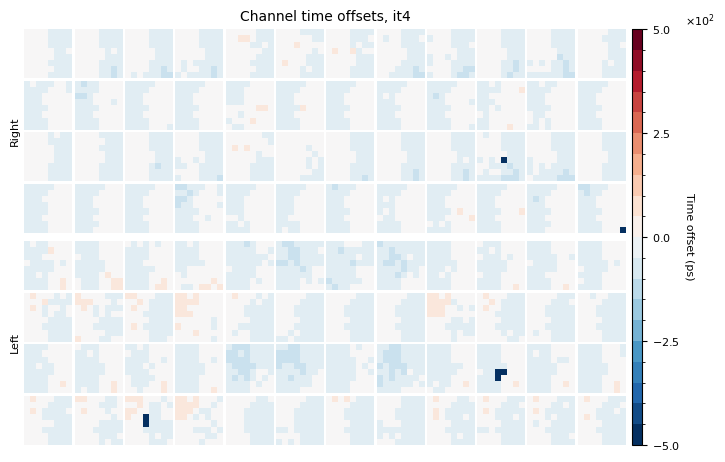

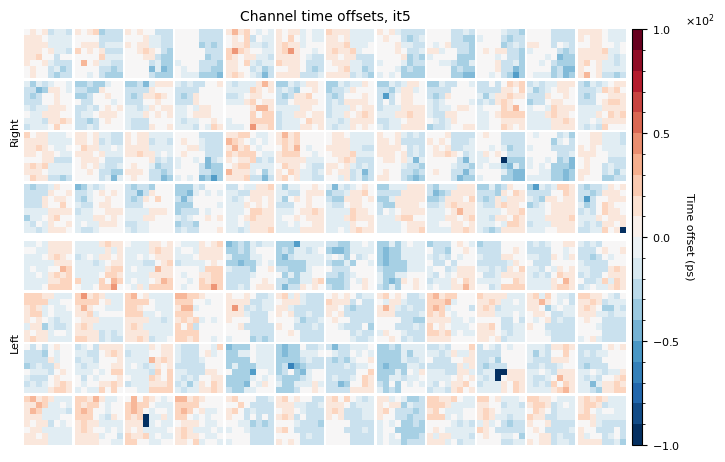

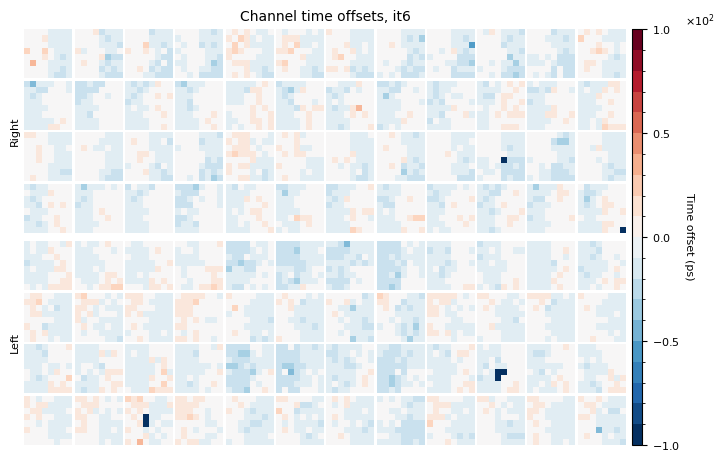

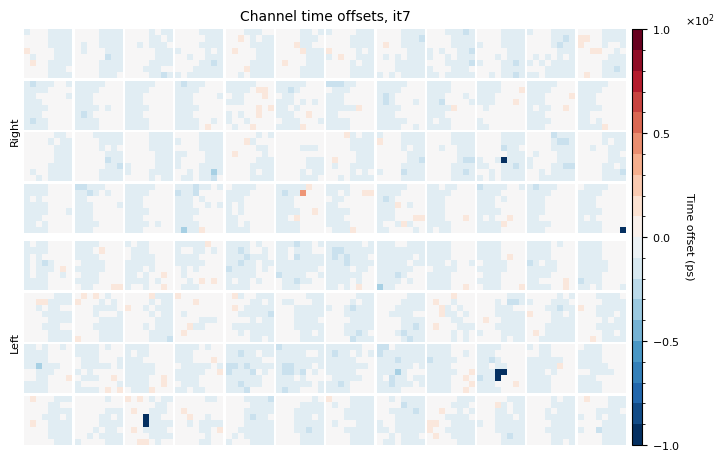

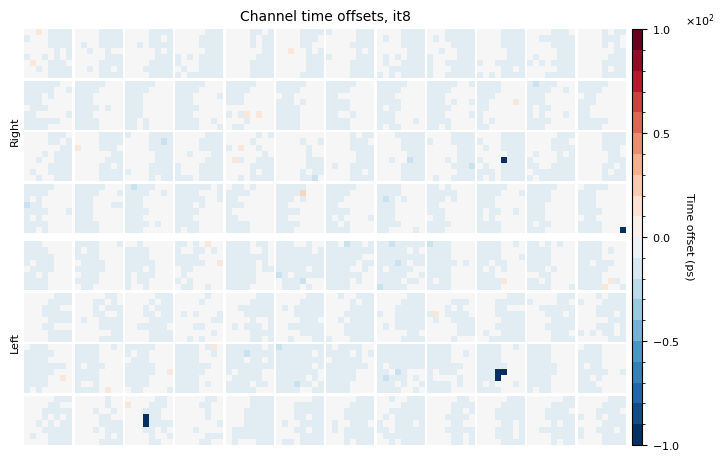

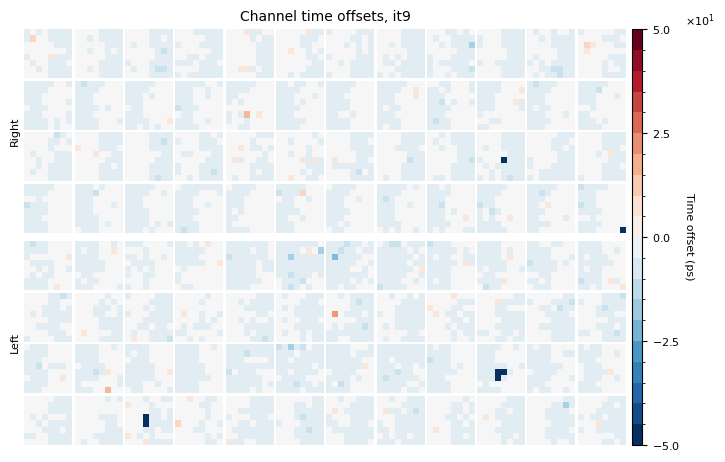

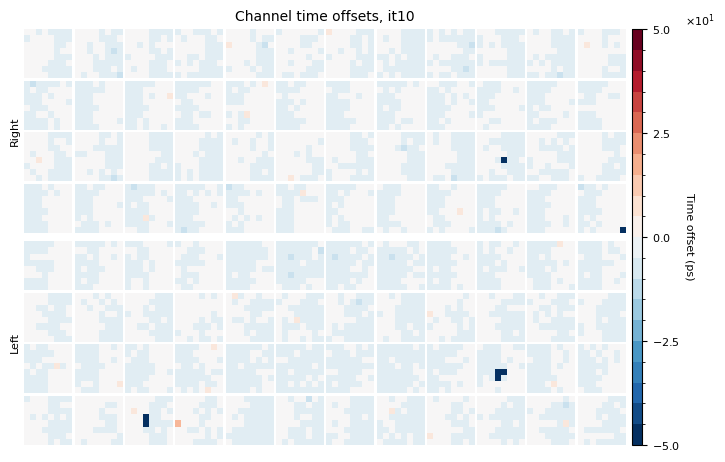

In [335]:
iterations = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
timerange = [1250, 1250, 500, 500, 500, 100, 100, 100, 100, 50, 50]
toffsets = []
tpath = '/home/kale-chen/Documents/PET/TPPT2026/data/'
toffsets0 = np.fromfile(os.path.join(tpath, 'tsvs',f'it1toffsets.bin'), dtype=np.float32)
toffsets.append(toffsets0)
heatmapL, heatmapR = prepheatmap(toffsets0)
heatmapmin, heatmapmax = -timerange[0], timerange[0]
makeheatmap(heatmapL, heatmapR, f'Channel time offsets, it0', 'Time offset (ps)', writeupdir + '/plots/timecalconv')
plt.show()
for it in iterations:
    toffsets1 = np.fromfile(os.path.join(tpath, 'tsvs',f'it{str(it+1)}toffsets.bin'), dtype=np.float32)
    toffsets.append(toffsets1)
    heatmapL, heatmapR = prepheatmap(toffsets1)
    heatmapmin, heatmapmax = -timerange[it], timerange[it]
    makeheatmap(heatmapL, heatmapR, f'Channel time offsets, it{it}', 'Time offset (ps)', writeupdir + '/plots/timecalconv')
    plt.show()

[33956.72121462   215.53143606   589.50600725]
[32115.22683368    46.80230815   273.73334773]
[3.2057831e+04 3.4499349e+00 6.7134149e+01]
[3.14050433e+04 3.99235926e-02 2.37556925e+00]


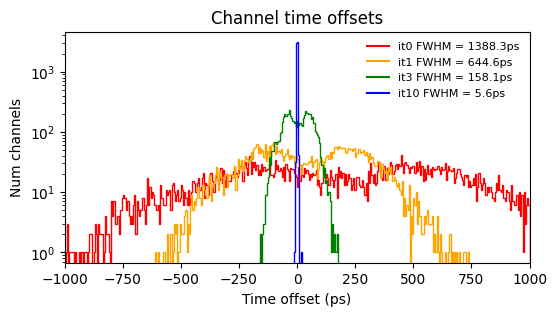

In [350]:
plt.figure(figsize = (6, 3))
bins = np.linspace(-1000, 1000, 401)
colors = ['red', 'orange', 'green', 'blue']
iterations = [0, 1, 3, 10]
for i in range(len(iterations)):
    hist = plt.hist(toffsets[iterations[i]], bins = bins, histtype = 'step', color = colors[i])[0]
    popt, _ = curve_fit(gaussian, bins[:-1] + np.diff(bins)[0] / 2, hist, p0 = [np.max(hist), 0, 1])
    plt.plot(0, 0, label = f'it{iterations[i]} FWHM = {2.355 * popt[2]:.1f}ps', color = colors[i])
    #plt.plot(np.linspace(-1000, 1000, 1000), gaussian(np.linspace(-1000, 1000, 1000), *popt), color = colors[i])
    print(popt)
plt.legend(loc = 'upper right', frameon = False, fontsize = 8)
plt.yscale('log')
plt.xlim(-1000, 1000)
plt.xlabel('Time offset (ps)')
plt.ylabel('Num channels')
plt.title('Channel time offsets')
plt.savefig('/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots/timecalconv/histselectediterations.pdf',format='pdf',dpi=300,bbox_inches='tight')

plt.show()

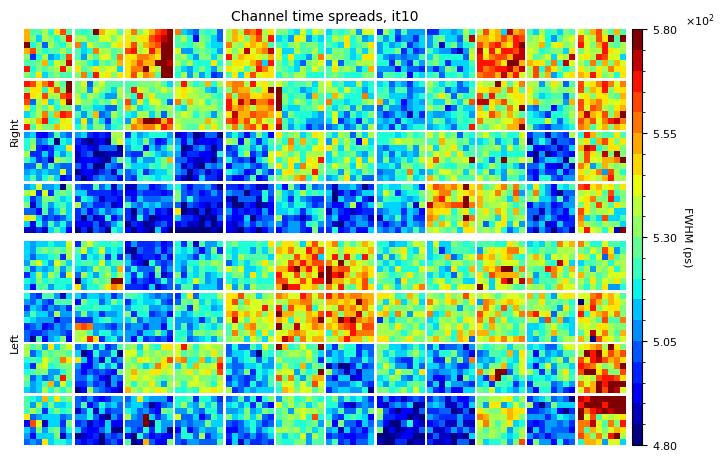

In [359]:
tspreads10 = np.fromfile(os.path.join(tpath, 'tsvs',f'it10tspreads.bin'), dtype=np.float32) * 2.355
heatmapL, heatmapR = prepheatmap(tspreads10)
setcmap('jet')
heatmapmin, heatmapmax = 480, 580
makeheatmap(heatmapL, heatmapR, title = 'Channel time spreads, it10', cbarlabel = 'FWHM (ps)', savedir = writeupdir + '/plots/timecalconv')
plt.show()